In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/06_industry_folio_count.csv")

df.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [4]:
# Check missing values
df.isnull().sum()

# Remove duplicates
df = df.drop_duplicates()

# Check data types
df.dtypes

# Save cleaned dataset
df.to_csv(
    "../data/processed/dataset6" \
    "_cleaned.csv",
    index=False
)

In [3]:
df.shape

(21, 6)

In [4]:
df.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

In [5]:
df.dtypes

month                      str
total_folios_crore     float64
equity_folios_crore    float64
debt_folios_crore      float64
hybrid_folios_crore    float64
others_folios_crore    float64
dtype: object

In [6]:
df["month"] = pd.to_datetime(df["month"])

df.dtypes

month                  datetime64[us]
total_folios_crore            float64
equity_folios_crore           float64
debt_folios_crore             float64
hybrid_folios_crore           float64
others_folios_crore           float64
dtype: object

In [7]:
df.isnull().sum()

month                  0
total_folios_crore     0
equity_folios_crore    0
debt_folios_crore      0
hybrid_folios_crore    0
others_folios_crore    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["month"].min(), df["month"].max()

(Timestamp('2022-01-01 00:00:00'), Timestamp('2025-12-01 00:00:00'))

In [10]:
df.describe()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
count,21,21.000000,21.000000,21.000000,21.000000,21.000000
mean,2024-03-31 22:51:25.714285,19.829524,13.880476,2.776190,1.190000,1.983333
min,2022-01-01 00:00:00,13.260000,9.280000,1.860000,0.800000,1.330000
25%,2023-04-01 00:00:00,15.540000,10.880000,2.180000,0.930000,1.550000
50%,2024-07-01 00:00:00,19.980000,13.990000,2.800000,1.200000,2.000000
75%,2025-04-01 00:00:00,23.890000,16.720000,3.340000,1.430000,2.390000
max,2025-12-01 00:00:00,26.120000,18.280000,3.660000,1.570000,2.610000
std,NaN,4.583376,3.207799,0.640308,0.274864,0.459079


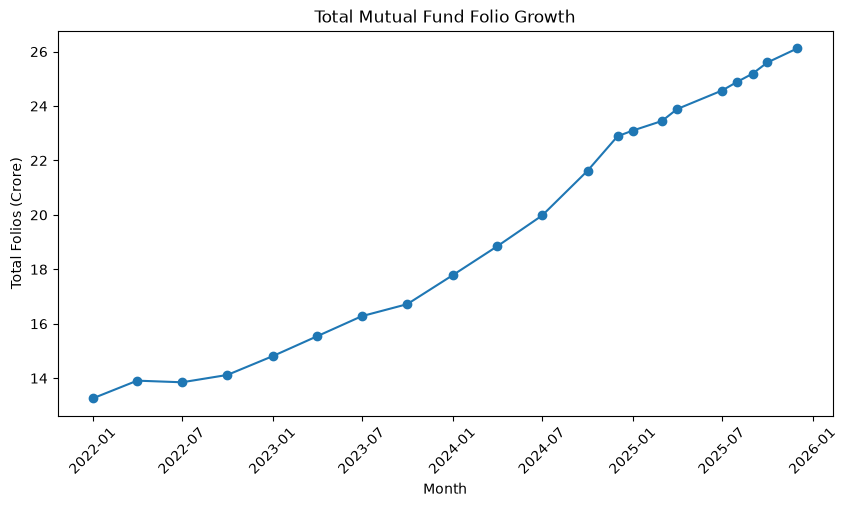

In [11]:
plt.figure(figsize=(10,5))

plt.plot(
    df["month"],
    df["total_folios_crore"],
    marker="o"
)

plt.title("Total Mutual Fund Folio Growth")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.xticks(rotation=45)

plt.show()

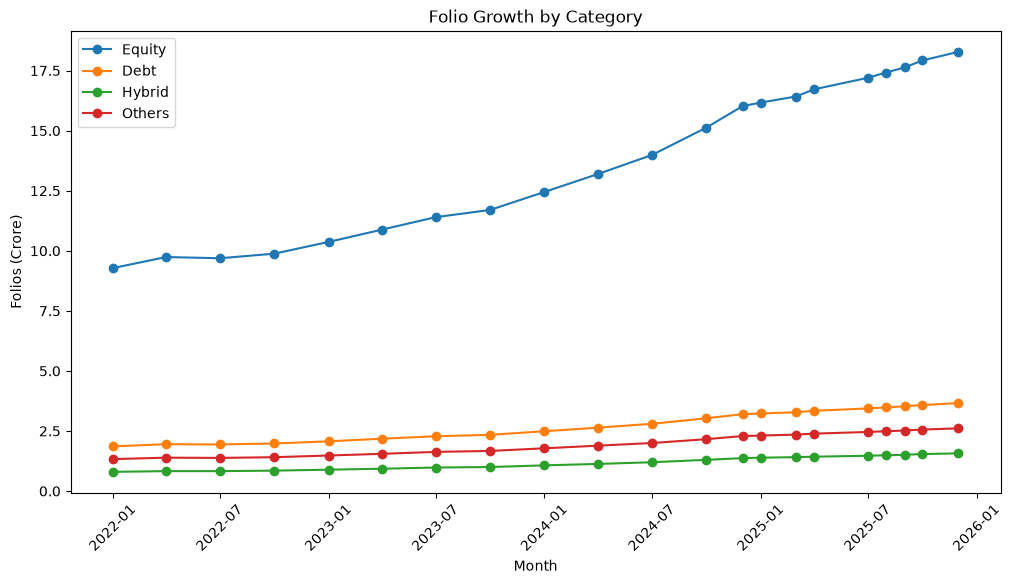

In [12]:
plt.figure(figsize=(12,6))

plt.plot(
    df["month"],
    df["equity_folios_crore"],
    marker="o",
    label="Equity"
)

plt.plot(
    df["month"],
    df["debt_folios_crore"],
    marker="o",
    label="Debt"
)

plt.plot(
    df["month"],
    df["hybrid_folios_crore"],
    marker="o",
    label="Hybrid"
)

plt.plot(
    df["month"],
    df["others_folios_crore"],
    marker="o",
    label="Others"
)


plt.title("Folio Growth by Category")

plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.legend()

plt.xticks(rotation=45)

plt.show()

In [13]:
latest = df.iloc[-1]

latest

month                  2025-12-01 00:00:00
total_folios_crore                   26.12
equity_folios_crore                  18.28
debt_folios_crore                     3.66
hybrid_folios_crore                   1.57
others_folios_crore                   2.61
Name: 20, dtype: object

In [14]:
folio_columns = [
    "equity_folios_crore",
    "debt_folios_crore",
    "hybrid_folios_crore",
    "others_folios_crore"
]


latest_folios = latest[folio_columns]


percentage = (
    latest_folios / latest["total_folios_crore"]
) * 100


percentage

equity_folios_crore    69.984686
debt_folios_crore      14.012251
hybrid_folios_crore      6.01072
others_folios_crore     9.992343
Name: 20, dtype: object

In [17]:
percentage = pd.to_numeric(percentage)

percentage

equity_folios_crore    69.984686
debt_folios_crore      14.012251
hybrid_folios_crore     6.010720
others_folios_crore     9.992343
Name: 20, dtype: float64

In [18]:
percentage.dtype

dtype('float64')

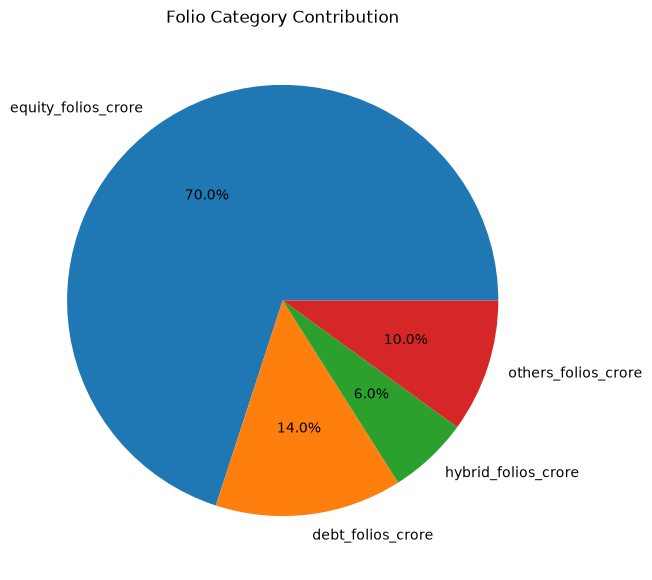

In [19]:
plt.figure(figsize=(7,7))

plt.pie(
    percentage.values,
    labels=percentage.index,
    autopct="%1.1f%%"
)

plt.title("Folio Category Contribution")

plt.show()

# Insights from Folio Growth Dataset

## Dataset Overview
- Dataset contains quarterly/monthly mutual fund folio statistics.
- Total records analyzed: 21.
- Categories include Equity, Debt, Hybrid and Others.

## Data Quality
- Month column converted into datetime format.
- No missing values found.
- No duplicate records found.

## Folio Growth Analysis
- Total mutual fund folios increased consistently over the analysis period.
- Equity funds contribute the largest share of investor folios.
- Debt and hybrid categories show steady growth.

## Key Observation
Growth in total folios indicates increasing participation of investors in mutual fund markets, with equity schemes being the major contributor.